In [1]:
import pandas 
from collections import defaultdict
import numpy as np
import demes
import moments 
import dpluspy
import demesdraw
import scipy
import matplotlib
import matplotlib.pylab as plt
import matplotlib.ticker


In [2]:
# Parse likelihoods from bootstrap reps

data_sets = [
    "Bherer",
    "ZhouJHS",
]

models = [
    "model_0",
    "model_1",
    "model_2"
]

ll_dict = {
    "data_set": [],
    "model": [],
    "rep": [],
    "ll": []
}

for data_set in data_sets:
    for model in models:
        for rep in range(100):
            fname = f"fitted_models/{model}_{data_set}_rep_{rep}.yaml"
            ll_dict["data_set"].append(data_set)
            ll_dict["model"].append(model)
            ll_dict["rep"].append(rep)
            ll = demes.load(fname).metadata["opt_info"]["ll"]
            ll_dict["ll"].append(ll)

df = pandas.DataFrame(ll_dict)
df.to_csv("lrt_table.csv", index=0)
print(df)

    data_set    model  rep          ll
0     Bherer  model_0    0 -586.573011
1     Bherer  model_0    1 -608.848545
2     Bherer  model_0    2 -548.205937
3     Bherer  model_0    3 -602.750661
4     Bherer  model_0    4 -680.345081
..       ...      ...  ...         ...
595  ZhouJHS  model_2   95 -500.557425
596  ZhouJHS  model_2   96 -536.514545
597  ZhouJHS  model_2   97 -417.228783
598  ZhouJHS  model_2   98 -436.471595
599  ZhouJHS  model_2   99 -466.228787

[600 rows x 4 columns]


In [3]:
# Compute replicate D and p-values

ll_0_b = np.array(df[(df["data_set"] == "Bherer") & (df["model"] == "model_0")]["ll"])
ll_1_b = np.array(df[(df["data_set"] == "Bherer") & (df["model"] == "model_1")]["ll"])
ll_2_b = np.array(df[(df["data_set"] == "Bherer") & (df["model"] == "model_2")]["ll"])

D_1_0_b = 2 * (ll_1_b - ll_0_b)
p_1_0_b = 1 - scipy.stats.chi2.cdf(D_1_0_b, 2)
D_2_0_b = 2 * (ll_2_b - ll_0_b)
p_2_0_b = 1 - scipy.stats.chi2.cdf(D_2_0_b, 3)
D_2_1_b = 2 * (ll_2_b - ll_1_b)
p_2_1_b = 1 - scipy.stats.chi2.cdf(D_2_1_b, 2)


ll_0_z = np.array(df[(df["data_set"] == "ZhouJHS") & (df["model"] == "model_0")]["ll"])
ll_1_z = np.array(df[(df["data_set"] == "ZhouJHS") & (df["model"] == "model_1")]["ll"])
ll_2_z = np.array(df[(df["data_set"] == "ZhouJHS") & (df["model"] == "model_2")]["ll"])

D_1_0_z = 2 * (ll_1_z - ll_0_z)
p_1_0_z = 1 - scipy.stats.chi2.cdf(D_1_0_z, 2)
D_2_0_z = 2 * (ll_2_z - ll_0_z)
p_2_0_z = 1 - scipy.stats.chi2.cdf(D_2_0_z, 3)
D_2_1_z = 2 * (ll_2_z - ll_1_z)
p_2_1_z = 1 - scipy.stats.chi2.cdf(D_2_1_z, 2)


In [4]:
print(np.min(D_2_1_b))

70.63100765342551


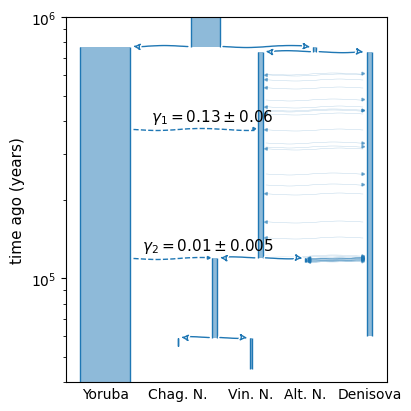

In [5]:
# graph figure
positions = {
    "Yoruba1": 0,
    "Anc": 55000,
    "ND": 115000,
    "WN": 60000,
    "Chagyrskaya": 40000,
    "Vindija": 80000,
    "N": 85000,
    "Altai": 110000,
    "Denisova": 145000,
}
graph = demes.load("../mass_fit_2/edited_models/human_neand_model_2.yaml")
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")
demesdraw.tubes(
    graph,
    ax=ax,
    max_time=1e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
samples = ["Yoruba1", "Vindija", "Chagyrskaya", "Altai", "Denisova"]
labels = ["Yoruba", "Vin. N.", "Chag. N.", "Alt. N.", "Denisova"]
xlocs = [positions[sample] for sample in samples]
ax.set_xticks(xlocs, labels)
ax.set_yticks([1e5, 1e6], [r"$10^5$", "$10^6$"])
ax.set_ylim(4e4,)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.annotate(r"$\gamma_1=0.13\pm 0.06$", (25000, 4e5))
ax.annotate(r"$\gamma_2=0.01\pm 0.005$", (20000, 1.28e5))

plt.savefig("figures/human_neanderthal_pulse_model.svg", transparent=True)

In [6]:
# bootstrap uncerts for model 2

param_file = "models/model_2_params.yaml"
pdict = defaultdict(list)

for rep in range(100):
    fname = f"fitted_models/model_2_Bherer_rep_{rep}.yaml"
    pnames, ps = dpluspy.inference._load_params(fname, param_file)
    for pname, p in zip(pnames, ps):
        pdict[pname].append(p)

param_df = pandas.DataFrame(pdict)
param_df.to_csv("model_2_Bherer_bootstrap_mle.csv", index=0)
print(param_df)

            T_NDH           T_ND          T_AWN          T_CV         N_Anc  \
0   777653.842053  724142.449286  121757.791868  59266.453518  16000.322395   
1   774083.082181  737802.064625  119597.165082  59893.121966  16194.025779   
2   763648.832989  723337.342696  120691.755652  59654.242738  16052.195933   
3   760014.283591  726322.228950  121531.588318  61945.868139  16532.852438   
4   765770.144672  746999.140304  121101.839990  60837.041848  16425.794254   
..            ...            ...            ...           ...           ...   
95  773558.850632  730549.216012  119158.903657  57843.154494  16089.215725   
96  762716.279677  743566.513045  123155.313496  63580.824212  16307.212371   
97  757274.963181  722021.777701  127083.994264  60739.956346  16257.693235   
98  785026.324653  735788.096299  125473.847078  58568.668475  16121.693263   
99  780422.475238  751124.664620  124034.761331  60790.940063  15800.193041   

           N_Yor         N_ND        N_Den         

In [7]:
for col in param_df.columns:
    print(col, 1.96 * np.std(param_df[col]))

T_NDH 31784.968405580898
T_ND 30901.84432722172
T_AWN 9027.612150249104
T_CV 3058.9796024626867
N_Anc 596.5541460524533
N_Yor 1364.1133204244886
N_ND 1364.1721237243978
N_Den 453.209544449879
N_N 268.76318835335115
N_Alt 762.4261326960976
N_Cha 164.57204119877483
N_Vin 241.52703348521203
m_AD 2.5222399134238337e-06
T_H_N 116581.65992461183
p_H_N 0.0685303917195147
p_H_WN 0.0052492708324580395


In [8]:
# models
graph0 = "../mass_fit_2/fitted_models/human_neand_model_0_Bherer_yor1_rep_22.yaml"
graph1 = "../mass_fit_2/fitted_models/human_neand_model_1_Bherer_yor1_rep_13.yaml"
graph2 = "../mass_fit_2/fitted_models/human_neand_model_2_Bherer_yor1_rep_16.yaml"

data_file = "../../../analyses/recombination_maps/stats/subset_Bherer.pkl"
u = 1.3e-8

data = dpluspy.inference.load_bootstrap_reps(
    data_file, graph=graph0, return_dict=True)

model0 = dpluspy.inference.compute_bin_stats(graph0, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model1 = dpluspy.inference.compute_bin_stats(graph1, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)
model2 = dpluspy.inference.compute_bin_stats(graph2, 
    sampled_demes=data["pop_ids"], bins=data["bins"], u=u)

In [9]:
def plot_on_ax(ax, data, models, stat, title, labels, colors):
    means = data["means"]
    v = data["varcovs"]
    bins = data["bins"]
    x = (bins[1:] + bins[:-1]) / 2
    pop_ids = data["pop_ids"]
    statistics = models[0].names()[0]
    k = statistics.index(stat)

    j = 0
    label = labels[j]
    err = np.array([v[l][k, k] ** 0.5 * 1.96 for l in range(len(x))])
    y = np.array([means[j][k] for j in range(len(x))])
    ax.fill_between(x, y - err, y + err, alpha=0.3, color=colors[j],
                    edgecolor='none')
    ax.plot(x, y, linestyle="dashed", color=colors[j], label=label)
    j += 1
    for model in models:
        label = labels[j]
        y = [model[l][k] for l in range(len(x))]
        ax.plot(x, y, color=colors[j], label=label)
        j += 1
    # ax setup
    ax.set_xscale("log")
    ax.set_title(title, y=0.80, fontsize=7)
    #ax.set_xlabel("$r$")
    #ax.set_xlabel("$D^+$")

In [10]:
print(model2.names())
print(model2.pop_ids)
stats = model2.names()[0]
pop_ids = model2.pop_ids
stats_to_plot = [
    "D+_Vindija_Vindija",
    "D+_Vindija_Denisova",
    "D+_Vindija_Yoruba1",
    "D+_Altai_Yoruba1",
]
_stats_to_plot = []
for stat in stats_to_plot:
    pop0, pop1 = stat.split("_")[1:]
    _stats_to_plot.append(f"D+_{pop_ids.index(pop0)}_{pop_ids.index(pop1)}")
print(_stats_to_plot)
idxs_to_plot = [stats.index(stat) for stat in _stats_to_plot]
print(idxs_to_plot)

(['D+_0_0', 'D+_0_1', 'D+_0_2', 'D+_0_3', 'D+_0_4', 'D+_1_1', 'D+_1_2', 'D+_1_3', 'D+_1_4', 'D+_2_2', 'D+_2_3', 'D+_2_4', 'D+_3_3', 'D+_3_4', 'D+_4_4'], ['H_0_0', 'H_0_1', 'H_0_2', 'H_0_3', 'H_0_4', 'H_1_1', 'H_1_2', 'H_1_3', 'H_1_4', 'H_2_2', 'H_2_3', 'H_2_4', 'H_3_3', 'H_3_4', 'H_4_4'])
['Altai', 'Vindija', 'Chagyrskaya', 'Denisova', 'Yoruba1']
['D+_1_1', 'D+_1_3', 'D+_1_4', 'D+_0_4']
[5, 7, 8, 4]


<>:57: DeprecationWarning: invalid escape sequence '\g'


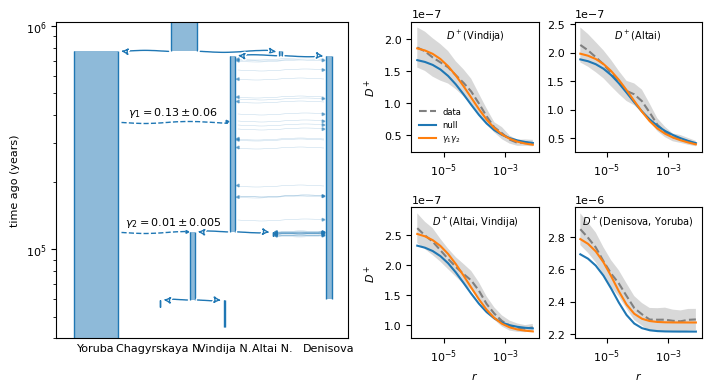

In [11]:
matplotlib.rc("font", size=8)
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)

mosaic = """
ABC
ADE
"""

fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 3.8), layout="constrained",
    width_ratios=[2.3, 1, 1])

#for label, ax in axs.items():
#    ax.set_title(label, loc='left', fontsize='medium')

# graph figure
ax = axs["A"]
positions = {
    "Yoruba1": 0,
    "Anc": 55000,
    "ND": 115000,
    "WN": 60000,
    "Chagyrskaya": 40000,
    "Vindija": 80000,
    "N": 85000,
    "Altai": 110000,
    "Denisova": 145000,
}
graph = demes.load("../mass_fit_2/edited_models/human_neand_model_2.yaml")
demesdraw.tubes(
    graph,
    ax=ax,
    max_time=1.05e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
samples = ["Yoruba1", "Vindija", "Chagyrskaya", "Altai", "Denisova"]
labels = ["Yoruba", "Vindija N.", "Chagyrskaya N.", "Altai N.", "Denisova"]
xlocs = [positions[sample] for sample in samples]
ax.set_xticks(xlocs, labels)
ax.set_yticks([1e5, 1e6], [r"$10^5$", "$10^6$"])
ax.set_ylim(4e4,)
ax.set_xlim(-2.5e4, 1.57e5)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.annotate(r"$\gamma_1=0.13\pm 0.06$", (20000, 4e5))
ax.annotate(r"$\gamma_2=0.01\pm 0.005$", (18000, 1.28e5))


plot_on_ax(axs["B"], data, [model0, model2], "D+_1_1",
    r"$D^+(\text{Vindija})$", ["data", "null", "$\gamma_1 \gamma_2$"],
    colors=["grey", "tab:blue", "tab:orange"])
axs["B"].legend(framealpha=0, fontsize=6, loc="lower left")

plot_on_ax(axs["C"], data, [model0, model2], "D+_0_0",
    r"$D^+(\text{Altai})$", ["data", "null", "$\gamma_1 \gamma_2$"],
    colors=["grey", "tab:blue", "tab:orange"])

plot_on_ax(axs["D"], data, [model0, model2], "D+_0_1",
    r"$D^+(\text{Altai, Vindija})$", ["data", "null", "$\gamma_1 \gamma_2$"],
    colors=["grey", "tab:blue", "tab:orange"])

plot_on_ax(axs["E"], data, [model0, model2], "D+_3_4",
    r"$D^+(\text{Denisova, Yoruba})$", ["data", "null", "$\gamma_1 \gamma_2$"],
    colors=["grey", "tab:blue", "tab:orange"])

axs["B"].sharex(axs["D"])
axs["C"].sharex(axs["E"])

axs["B"].set_ylabel("$D^+$")
axs["D"].set_ylabel("$D^+$")

axs["D"].set_xlabel("$r$")
axs["E"].set_xlabel("$r$")

plt.savefig("figures/big_figure.svg", transparent=True)


AttributeError: 'numpy.ndarray' object has no attribute 'names'

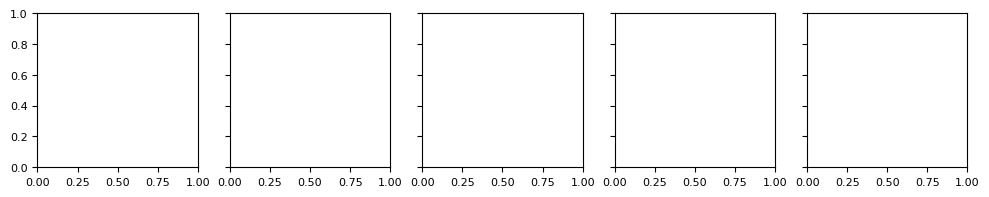

In [12]:
fig, axs = plt.subplots(1, 5, figsize=(12, 2), sharey=True)
plot_on_ax(
    axs[0], 
    data, 
    model0, 
    ["D+_3_3", "D+_3_4"],
    ["X", "XY"],
    ["tab:blue", "tab:orange"],
    r"Model null $D^+(X)$"
)
axs[0].legend(framealpha=0, fontsize=6, loc="upper right")
plot_on_ax(
    axs[1], 
    data, 
    model0, 
    ["D+_0_0", "D+_0_3", "D+_0_4"],
    ["X", "XD", "XY"],
    ["tab:blue", "tab:green", "tab:orange"],
    r"Model null $D^+(X)$"
)
plot_on_ax(
    axs[2], 
    data, 
    model0, 
    ["D+_1_1", "D+_1_3", "D+_1_4"],
    ["X", "XD", "XY"],
    ["tab:blue", "tab:green", "tab:orange"],
    r"Model null $D^+(X)$"
)
plot_on_ax(
    axs[3], 
    data, 
    model0, 
    ["D+_2_2", "D+_2_3", "D+_2_4"],
    ["X", "XD", "XY"],
    ["tab:blue", "tab:green", "tab:orange"],
    r"Model null $D^+(X)$"
)

plot_on_ax(
    axs[4], 
    data, 
    model0, 
    ["D+_0_0", "D+_1_1", "D+_2_2"],
    ["1", "2", "3"],
    ["tab:blue", "tab:green", "tab:orange"],
    r"Model null $D^+(X)$"
)

axs[1].set_yscale("log")

axs[1].legend(framealpha=0, fontsize=6, loc="upper right")

In [13]:
def plot_on_ax(ax, data, model, stats, labels, colors, title):
    means = data["means"]
    v = data["varcovs"]
    bins = data["bins"]
    x = (bins[1:] + bins[:-1]) / 2
    pop_ids = data["pop_ids"]
    statistics = model.names()[0]

    for j, stat in enumerate(stats):
        k = statistics.index(stat)
        label = labels[j]
        err = np.array([v[l][k, k] ** 0.5 * 1.96 for l in range(len(x))])
        y = np.array([means[j][k] for j in range(len(x))])
        ax.fill_between(x, y - err, y + err, alpha=0.3, color=colors[j],
                        edgecolor='none')
        ax.plot(x, y, linestyle="dashed", color=colors[j])
        y = [model[l][k] for l in range(len(x))]
        ax.plot(x, y, color=colors[j], label=label)
    # ax setup
    # logfmt = matplotlib.ticker.LogFormatterExponent(base=10.0, labelOnlyBase=True)
    # ax.yaxis.set_major_formatter(logfmt)
    ax.set_xscale("log")
    ax.set_title(title, fontsize=7,)
    #ax.set_xlabel("$r$")
    #ax.set_xlabel("$D^+$")


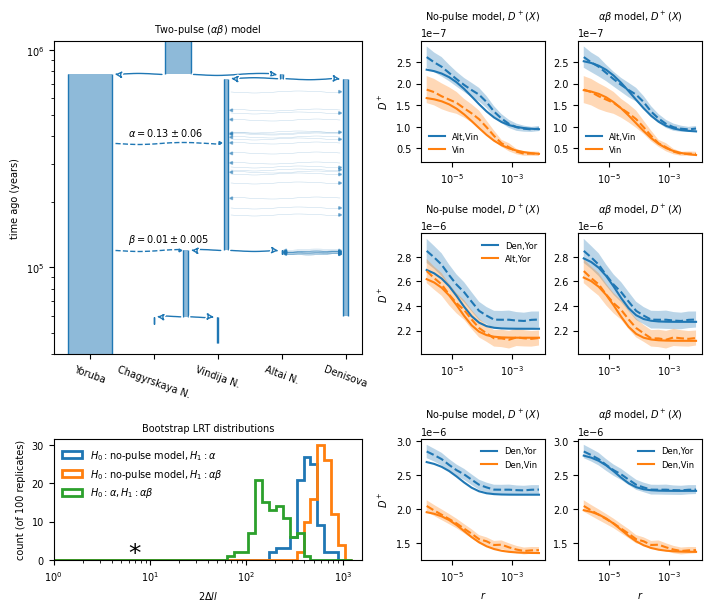

In [15]:
matplotlib.rc("font", size=7)
matplotlib.rc("xtick", labelsize=7)
matplotlib.rc("ytick", labelsize=7)
matplotlib.rc("axes", labelsize=7)
matplotlib.rc("axes", titlesize=7)
matplotlib.rc("legend", fontsize=7)

mosaic = """
ABC
ADE
FGH
"""
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7, 6), layout="constrained",
    width_ratios=[2.5, 1, 1])


graph = demes.load("../mass_fit_2/edited_models/human_neand_model_2.yaml")
positions = {
    "Yoruba1": 0,
    "Anc": 55000,
    "ND": 120000,
    "WN": 60000,
    "Chagyrskaya": 40000,
    "Vindija": 80000,
    "N": 85000,
    "Altai": 120000,
    "Denisova": 160000,
}
samples = ["Yoruba1", "Vindija", "Chagyrskaya", "Altai", "Denisova"]
labels = ["Yoruba", "Vindija N.", "Chagyrskaya N.", "Altai N.", "Denisova"]

axs["A"].set_title(r"Two-pulse ($\alpha \beta$) model")
demesdraw.tubes(
    graph,
    ax=axs["A"],
    max_time=1.1e6,
    log_time=True,
    labels=None,
    colours="tab:blue",
    positions=positions
)
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)
xlocs = [positions[sample] for sample in samples]
axs["A"].tick_params(axis="x", reset=True, bottom=True, top=False)
axs["A"].set_xticks(xlocs, labels, rotation=-20)
axs["A"].set_ylim(4e4, )
axs["A"].annotate(r"$\alpha=0.13\pm 0.06$", (24000, 4e5))
axs["A"].annotate(r"$\beta=0.01\pm 0.005$", (24000, 1.3e5))


bins = np.concatenate([[0], np.logspace(1, 3.1, 30)])
axs["F"].hist(D_1_0_b, bins=bins, fill=False, edgecolor="tab:blue", linewidth=2, 
    histtype="step", label=r"$H_0: \text{no-pulse model}, H_1: \alpha$")
axs["F"].hist(D_2_0_b, bins=bins, fill=False, edgecolor="tab:orange", linewidth=2, 
    histtype="step", label=r"$H_0: \text{no-pulse model}, H_1: \alpha \beta$")
axs["F"].hist(D_2_1_b, bins=bins, fill=False, edgecolor="tab:green", linewidth=2, 
    histtype="step", label=r"$H_0: \alpha, H_1: \alpha \beta$")
axs["F"].set_xscale("log")
axs["F"].annotate("*", (scipy.stats.chi2.ppf(0.95, 2), 0), color="black",
    fontsize=18)
axs["F"].set_xlim(1,)
axs["F"].set_ylabel("count (of 100 replicates)")
axs["F"].set_xlabel(r"$2\Delta ll$")
axs["F"].legend(framealpha=0, loc="upper left")
axs["F"].set_title("Bootstrap LRT distributions")


plot_on_ax(
    axs["B"], 
    data, 
    model0, 
    ["D+_0_1", "D+_1_1"],
    ["Alt,Vin", "Vin"],
    ["tab:blue", "tab:orange"],
    r"No-pulse model, $D^+(X)$"
)
axs["B"].legend(framealpha=0, fontsize=6, loc="lower left")
plot_on_ax(
    axs["C"], 
    data, 
    model2, 
    ["D+_0_1", "D+_1_1"],
    ["Alt,Vin", "Vin"],
    ["tab:blue", "tab:orange"],
    r"$\alpha \beta$ model, $D^+(X)$"
)
axs["C"].legend(framealpha=0, fontsize=6, loc="lower left")
axs["B"].sharey(axs["C"])


plot_on_ax(
    axs["D"], 
    data, 
    model0, 
    ["D+_3_4", "D+_0_4"],
    ["Den,Yor", "Alt,Yor"],
    ["tab:blue", "tab:orange"],
    r"No-pulse model, $D^+(X)$"
)
axs["D"].legend(framealpha=0, fontsize=6, loc="upper right")
plot_on_ax(
    axs["E"], 
    data, 
    model2, 
    ["D+_3_4", "D+_0_4"],
    ["Den,Yor", "Alt,Yor"],
    ["tab:blue", "tab:orange"],
    r"$\alpha \beta$ model, $D^+(X)$"
)

plot_on_ax(
    axs["G"], 
    data, 
    model0, 
    ["D+_3_4", "D+_1_3"],
    ["Den,Yor", "Den,Vin"],
    ["tab:blue", "tab:orange"],
    r"No-pulse model, $D^+(X)$"
)
axs["G"].legend(framealpha=0, fontsize=6, loc="upper right")
plot_on_ax(
    axs["H"], 
    data, 
    model2, 
    ["D+_3_4", "D+_1_3"],
    ["Den,Yor", "Den,Vin"],
    ["tab:blue", "tab:orange"],
    r"$\alpha \beta$ model, $D^+(X)$"
)
axs["H"].legend(framealpha=0, fontsize=6, loc="best")
axs["H"].sharey(axs["G"])

# labels
axs["B"].set_ylabel("$D^+$")
axs["D"].set_ylabel("$D^+$")
axs["G"].set_ylabel("$D^+$")

axs["H"].set_xlabel("$r$")
axs["B"].sharex(axs["G"])
axs["D"].sharex(axs["G"])
axs["G"].set_xlabel("$r$")
axs["C"].sharex(axs["H"])
axs["E"].sharex(axs["H"])


plt.savefig("figures/bigger_figure.svg", transparent=True)

